<h3 style="color:yellow">Importing Important Libraries</h3>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from warnings import filterwarnings
filterwarnings('ignore')

In [4]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn

<h3 style="color:red">Load Dataset</h3>

In [5]:
calendar = pd.read_csv("calendar.csv")
sales = pd.read_csv("sales_train_validation.csv")
prices = pd.read_csv("sell_prices.csv")

sales = sales.head(1000)

In [6]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [7]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [8]:
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


<h3 style="color:yellow">Dataset Shape</h3>

In [9]:
print("Calendar Shape :", calendar.shape)
print("Sales Shape :", sales.shape)
print("Prices Shape :", prices.shape)

Calendar Shape : (1969, 14)
Sales Shape : (1000, 1919)
Prices Shape : (6841121, 4)


In [10]:
calendar.info()

<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          1969 non-null   str  
 1   wm_yr_wk      1969 non-null   int64
 2   weekday       1969 non-null   str  
 3   wday          1969 non-null   int64
 4   month         1969 non-null   int64
 5   year          1969 non-null   int64
 6   d             1969 non-null   str  
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
 11  snap_CA       1969 non-null   int64
 12  snap_TX       1969 non-null   int64
 13  snap_WI       1969 non-null   int64
dtypes: int64(7), str(7)
memory usage: 215.5 KB


In [11]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), str(6)
memory usage: 14.6 MB


In [12]:
prices.info()

<class 'pandas.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    str    
 1   item_id     str    
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 208.8 MB


In [13]:
#Missing Values
calendar.isnull().sum()

date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64

In [14]:
sales.isnull().sum()

id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
           ..
d_1909      0
d_1910      0
d_1911      0
d_1912      0
d_1913      0
Length: 1919, dtype: int64

In [15]:
prices.isnull().sum()

store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

In [16]:
#Duplicate Values
print(calendar.duplicated().sum())
print(sales.duplicated().sum())
print(prices.duplicated().sum())

0
0
0


In [17]:
#Statastical Summary
calendar.describe(include='all')

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
count,1969,1969.000000,1969,1969.000000,1969.000000,1969.000000,1969,162,162,5,5,1969.000000,1969.000000,1969.000000
unique,1969,NaN,7,NaN,NaN,NaN,1969,30,4,4,2,NaN,NaN,NaN
top,2011-01-29,NaN,Saturday,NaN,NaN,NaN,d_1,SuperBowl,Religious,Father's day,Cultural,NaN,NaN,NaN
freq,1,NaN,282,NaN,NaN,NaN,1,6,55,2,4,NaN,NaN,NaN
mean,NaN,11347.086338,NaN,3.997461,6.325546,2013.288471,NaN,NaN,NaN,NaN,NaN,0.330117,0.330117,0.330117
std,NaN,155.277043,NaN,2.001141,3.416864,1.580198,NaN,NaN,NaN,NaN,NaN,0.470374,0.470374,0.470374
min,NaN,11101.000000,NaN,1.000000,1.000000,2011.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
25%,NaN,11219.000000,NaN,2.000000,3.000000,2012.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
50%,NaN,11337.000000,NaN,4.000000,6.000000,2013.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
75%,NaN,11502.000000,NaN,6.000000,9.000000,2015.000000,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000


In [18]:
sales.describe()

,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.84900,0.771000,0.643000,0.602000,0.427000,0.693000,0.565000,1.178000,0.7150,0.575000,...,0.932000,1.493000,1.472000,1.11300,1.004000,0.884000,0.883000,1.089000,1.403000,1.504000
std,3.37455,3.443605,3.128472,2.308013,1.699282,3.358278,1.948222,4.603423,2.5769,2.538665,...,1.993326,3.451937,3.273826,2.65052,2.041115,1.960711,1.985259,2.128288,2.515337,2.928577
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
75%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,...,1.000000,2.000000,2.000000,1.00000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000
max,54.00000,73.000000,67.000000,33.000000,29.000000,74.000000,26.000000,78.000000,30.0000,36.000000,...,22.000000,49.000000,44.000000,37.00000,28.000000,28.000000,24.000000,20.000000,23.000000,35.000000


In [19]:
prices.describe()

,wm_yr_wk,sell_price
count,6.841121e+06,6.841121e+06
mean,1.138294e+04,4.410952e+00
std,1.486100e+02,3.408814e+00
min,1.110100e+04,1.000000e-02
25%,1.124700e+04,2.180000e+00
50%,1.141100e+04,3.470000e+00
75%,1.151700e+04,5.840000e+00
max,1.162100e+04,1.073200e+02


In [20]:
#Convert Date
calendar['date'] = pd.to_datetime(calendar['date'])

In [21]:
#Data Types
calendar.dtypes

date            datetime64[us]
wm_yr_wk                 int64
weekday                    str
wday                     int64
month                    int64
year                     int64
d                          str
event_name_1               str
event_type_1               str
event_name_2               str
event_type_2               str
snap_CA                  int64
snap_TX                  int64
snap_WI                  int64
dtype: object

<h2 style="color:yellow">Monthly Distribution</h2>

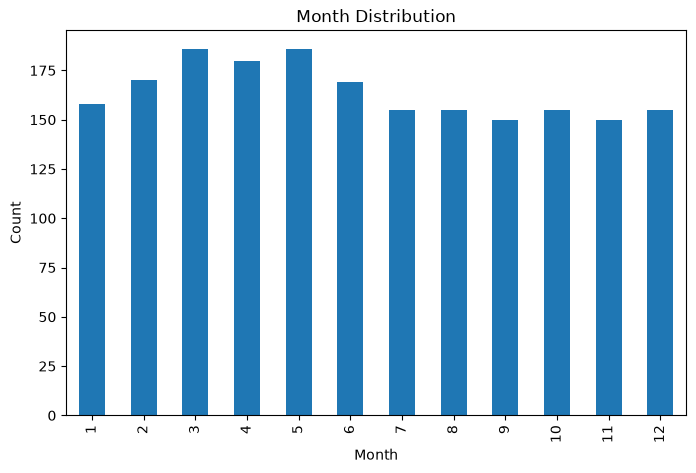

In [22]:
calendar['month'].value_counts().sort_index().plot(kind='bar',figsize=(8,5))

plt.title("Month Distribution")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

<h2 style="color:yellow">Weekday Distribution</h2>

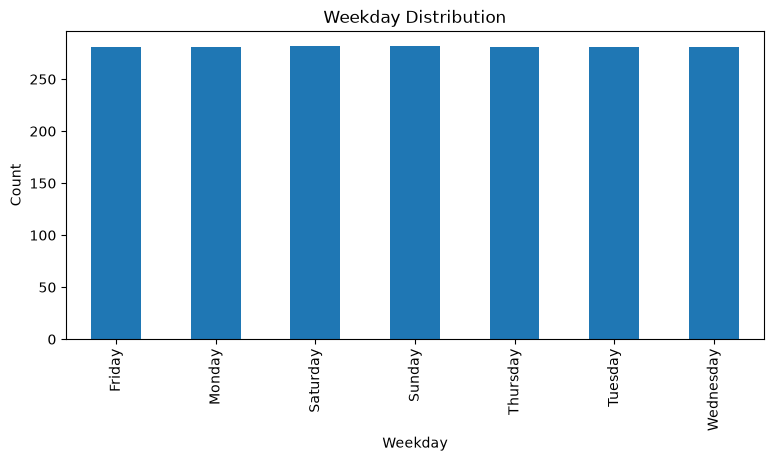

In [23]:
calendar['weekday'].value_counts().sort_index().plot(kind='bar',figsize=(9,4))

plt.title("Weekday Distribution")
plt.xlabel("Weekday")
plt.ylabel("Count")
plt.show()

<h2 style="color:yellow">Event Type</h2>

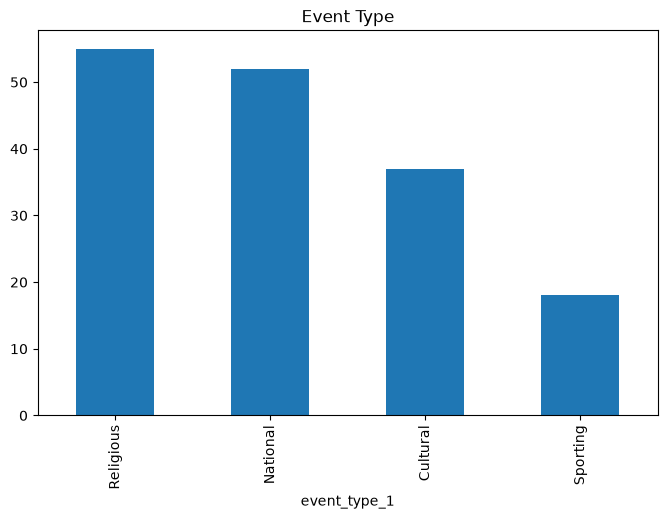

In [24]:
calendar['event_type_1'].value_counts().plot(kind='bar', figsize=(8,5))

plt.title("Event Type")
plt.show()

<h2 style="color:yellow">Price Distribution</h2>
Prize Vs Frequency

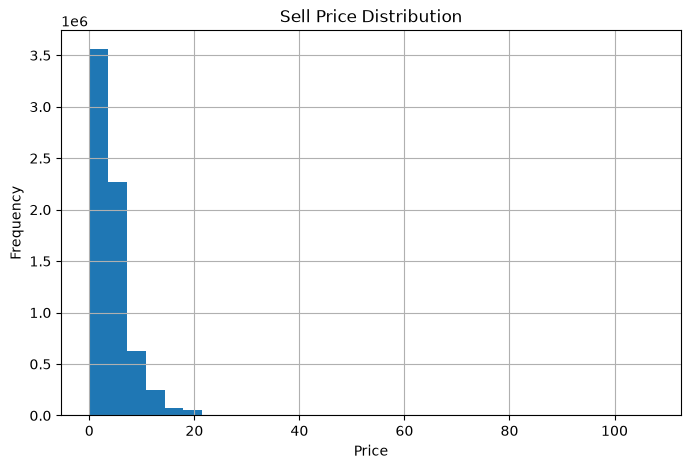

In [25]:
prices['sell_price'].hist(figsize=(8,5), bins=30)

plt.title("Sell Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [26]:
##Lowest Price
prices.sort_values("sell_price",ascending=False).head(10)

,store_id,item_id,wm_yr_wk,sell_price
6485947,WI_3,HOUSEHOLD_2_406,11319,107.32
6485945,WI_3,HOUSEHOLD_2_406,11317,107.32
6485946,WI_3,HOUSEHOLD_2_406,11318,107.32
5805276,WI_2,HOUSEHOLD_2_406,11242,61.46
5805279,WI_2,HOUSEHOLD_2_406,11245,61.46
5805278,WI_2,HOUSEHOLD_2_406,11244,61.46
5805277,WI_2,HOUSEHOLD_2_406,11243,61.46
5805283,WI_2,HOUSEHOLD_2_406,11249,61.46
5805280,WI_2,HOUSEHOLD_2_406,11246,61.46
5805281,WI_2,HOUSEHOLD_2_406,11247,61.46


In [27]:
##Lowest Price
prices.sort_values("sell_price").head(10)

,store_id,item_id,wm_yr_wk,sell_price
6282349,WI_3,HOUSEHOLD_1_036,11444,0.01
5316537,WI_1,FOODS_3_122,11425,0.01
6282348,WI_3,HOUSEHOLD_1_036,11443,0.01
6282347,WI_3,HOUSEHOLD_1_036,11442,0.01
1394086,CA_3,HOBBIES_1_261,11333,0.01
1394087,CA_3,HOBBIES_1_261,11334,0.01
1394085,CA_3,HOBBIES_1_261,11332,0.01
2617306,CA_4,FOODS_3_413,11148,0.01
225727,CA_1,HOUSEHOLD_1_443,11442,0.01
5044267,WI_1,HOUSEHOLD_1_533,11408,0.01


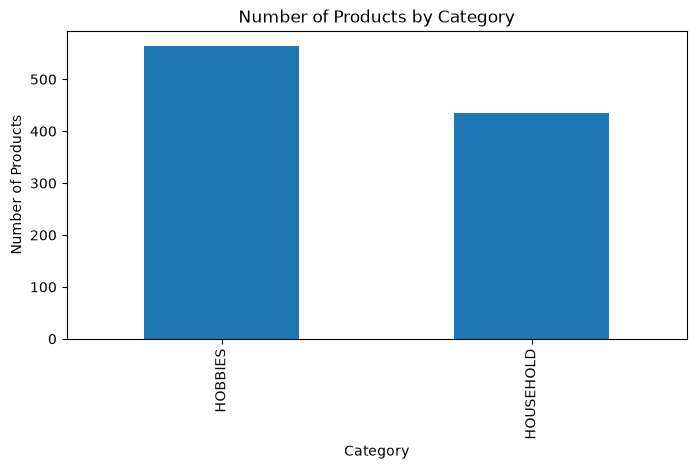

In [28]:
## Total Products in each Category
sales['cat_id'].value_counts().plot(kind='bar', figsize=(8,4))

plt.title("Number of Products by Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.show()

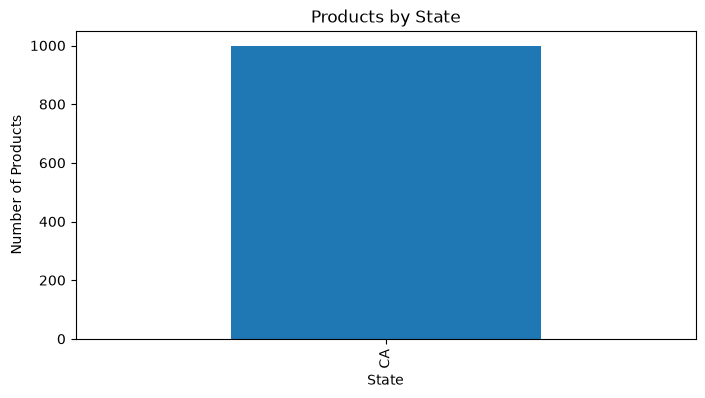

In [29]:
##Total Products by state 
sales['state_id'].value_counts().plot(kind='bar',figsize=(8,4))

plt.title("Products by State")
plt.xlabel("State")
plt.ylabel("Number of Products")
plt.show()

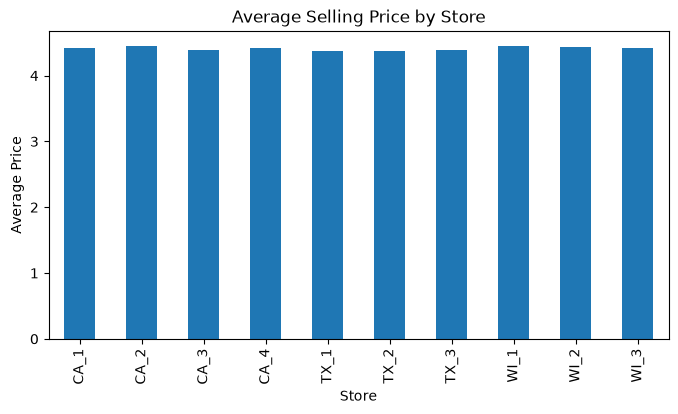

In [30]:
##Average Selling Price by Store
avg_price = prices.groupby('store_id')['sell_price'].mean()

avg_price.plot(kind='bar',figsize=(8,4))

plt.title("Average Selling Price by Store")
plt.xlabel("Store")
plt.ylabel("Average Price")
plt.show()

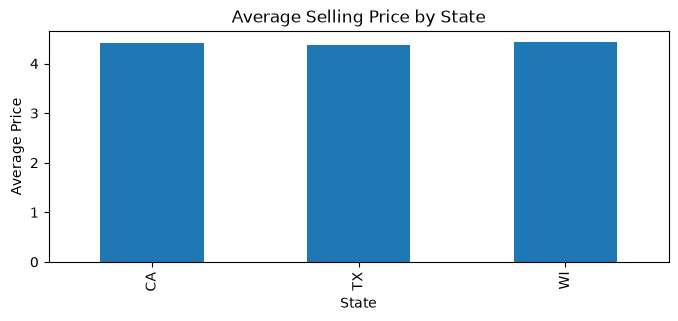

In [31]:
##Average Selling Price by State
prices['state'] = prices['store_id'].str[:2]

avg_state = prices.groupby('state')['sell_price'].mean()
avg_state.plot(kind='bar',figsize=(8,3))

plt.title("Average Selling Price by State")
plt.xlabel("State")
plt.ylabel("Average Price")
plt.show()

In [32]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [33]:
print(sales.columns[:10])
print(sales.columns[:-10])

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1',
       'd_2', 'd_3', 'd_4'],
      dtype='str')
Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1',
       'd_2', 'd_3', 'd_4',
       ...
       'd_1894', 'd_1895', 'd_1896', 'd_1897', 'd_1898', 'd_1899', 'd_1900',
       'd_1901', 'd_1902', 'd_1903'],
      dtype='str', length=1909)


In [34]:
print(sales.loc[0, 'd_1':'d_10'])

d_1     0
d_2     0
d_3     0
d_4     0
d_5     0
d_6     0
d_7     0
d_8     0
d_9     0
d_10    0
Name: 0, dtype: object


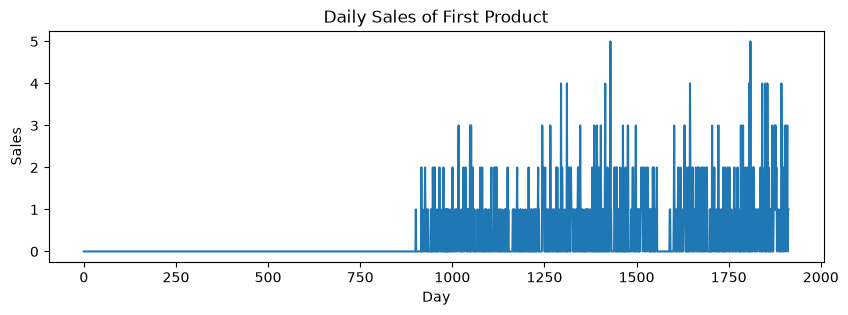

In [35]:
##Sample Daily Sales
sample = sales.loc[0, 'd_1':]

sample = sample.astype(int)

plt.figure(figsize=(10,3))
plt.plot(sample.values)

plt.title("Daily Sales of First Product")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.show()

In [36]:
##Top Selling Products

sales['Total_Sales'] = sales.loc[:, 'd_1':].sum(axis=1)

top_products = sales[['item_id','Total_Sales']].sort_values(
    by='Total_Sales',ascending=False)

top_products.head(10)

,item_id,Total_Sales
339,HOBBIES_1_348,22744
362,HOBBIES_1_371,22595
260,HOBBIES_1_268,18904
173,HOBBIES_1_178,15808
248,HOBBIES_1_256,15419
246,HOBBIES_1_254,15041
678,HOUSEHOLD_1_118,14604
361,HOBBIES_1_370,14565
332,HOBBIES_1_341,14152
47,HOBBIES_1_048,13867


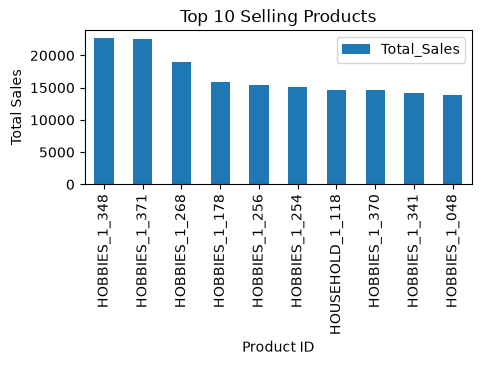

In [37]:
top_products.head(10).plot(x='item_id',y='Total_Sales',kind='bar',figsize=(5,2))

plt.title("Top 10 Selling Products")
plt.xlabel("Product ID")
plt.ylabel("Total Sales")
plt.show()

<h1 style='color:yellow'>Data Transformation</h1>

In [38]:
##Convert Sales Data(Wide to Long Format)

sales_subset = sales.head(200)

sales_long = sales_subset.melt(id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
                     var_name='d', value_name='sales')

sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [39]:
##Merge Sales Data with Calendar

sales_calendar = sales_long.merge(calendar, on='d',how='left')

sales_calendar.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101.0,...,1.0,1.0,2011.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101.0,...,1.0,1.0,2011.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101.0,...,1.0,1.0,2011.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101.0,...,1.0,1.0,2011.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101.0,...,1.0,1.0,2011.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0


In [40]:
##Merge with Selling Prices

merged_data = sales_calendar.merge(prices,on=['store_id', 'item_id', 'wm_yr_wk'], how='left')

merged_data.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,state
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101.0,...,2011.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101.0,...,2011.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101.0,...,2011.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101.0,...,2011.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101.0,...,2011.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN


In [41]:
merged_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 382800 entries, 0 to 382799
Data columns (total 23 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            382800 non-null  str           
 1   item_id       382800 non-null  str           
 2   dept_id       382800 non-null  str           
 3   cat_id        382800 non-null  str           
 4   store_id      382800 non-null  str           
 5   state_id      382800 non-null  str           
 6   d             382800 non-null  str           
 7   sales         382800 non-null  int64         
 8   date          382600 non-null  datetime64[us]
 9   wm_yr_wk      382600 non-null  float64       
 10  weekday       382600 non-null  str           
 11  wday          382600 non-null  float64       
 12  month         382600 non-null  float64       
 13  year          382600 non-null  float64       
 14  event_name_1  30800 non-null   str           
 15  event_type_1  30800 non-null

In [42]:
merged_data.shape

(382800, 23)

In [43]:
##Missig Values
merged_data.isnull().sum()

id                   0
item_id              0
dept_id              0
cat_id               0
store_id             0
state_id             0
d                    0
sales                0
date               200
wm_yr_wk           200
weekday            200
wday               200
month              200
year               200
event_name_1    352000
event_type_1    352000
event_name_2    382000
event_type_2    382000
snap_CA            200
snap_TX            200
snap_WI            200
sell_price       74008
state            74008
dtype: int64

In [44]:
##Handling Missing Values
merged_data['sell_price'] = merged_data['sell_price'].fillna(merged_data['sell_price'].median())

merged_data['event_name_1'] = merged_data['event_name_1'].fillna('No Event')
merged_data['event_type_1'] = merged_data['event_type_1'].fillna('No Event')
merged_data['event_name_2'] = merged_data['event_name_2'].fillna('No Event')
merged_data['event_type_2'] = merged_data['event_type_2'].fillna('No Event')

## Feature Engineering

In [45]:
##Create Features
merged_data['Year'] = merged_data['date'].dt.year
merged_data['Month'] = merged_data['date'].dt.month
merged_data['Day'] = merged_data['date'].dt.day
merged_data['Week'] = merged_data['date'].dt.isocalendar().week
merged_data['Weekday'] = merged_data['date'].dt.day_name()

In [46]:
print(merged_data[['date', 'Year', 'Month', 'Day', 'Week', 'Weekday']].head())

        date    Year  Month   Day  Week   Weekday
0 2011-01-29  2011.0    1.0  29.0     4  Saturday
1 2011-01-29  2011.0    1.0  29.0     4  Saturday
2 2011-01-29  2011.0    1.0  29.0     4  Saturday
3 2011-01-29  2011.0    1.0  29.0     4  Saturday
4 2011-01-29  2011.0    1.0  29.0     4  Saturday


In [47]:
##Revenue

merged_data['Revenue'] = (merged_data['sales'] *merged_data['sell_price'])

In [48]:
##Weekly Sales

weekly_sales = merged_data.groupby(['Year','Week'])['sales'].sum().reset_index()

weekly_sales.head()

,Year,Week,sales
0,2011.0,4,349
1,2011.0,5,1080
2,2011.0,6,1083
3,2011.0,7,1022
4,2011.0,8,1036


In [49]:
##Monthly Sales
monthly_sales = merged_data.groupby(
    ['Year','Month']
)['sales'].sum().reset_index()

monthly_sales.head()

,Year,Month,sales
0,2011.0,1.0,484
1,2011.0,2.0,4159
2,2011.0,3.0,4313
3,2011.0,4.0,4467
4,2011.0,5.0,4312


In [51]:
## Save Dataset

merged_data.to_csv("processed_data.csv", index=False)